<a href="https://colab.research.google.com/github/rohini-th/Ai/blob/main/Final_review.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [22]:
import pandas as pd

df = pd.read_csv(
    "/content/Reviews.csv",
    usecols=["Text"],
    nrows=1000,
    engine="python",
    on_bad_lines="skip"
)


In [23]:
import re

def clean_text(text):
    text = str(text).lower()
    text = re.sub(r'[^a-zA-Z ]', ' ', text)
    text = re.sub(r'\s+', ' ', text)
    return text.strip()

df["Text"] = df["Text"].apply(clean_text)
df = df[df["Text"] != ""]

In [24]:
from tensorflow.keras.preprocessing.text import Tokenizer

tokenizer = Tokenizer(num_words=1000, oov_token="<OOV>")
tokenizer.fit_on_texts(df["Text"])

total_words = 1000

In [25]:
input_sequences = []

for sentence in df["Text"]:
    token_list = tokenizer.texts_to_sequences([sentence])[0]

    for i in range(1, len(token_list)):
        input_sequences.append(token_list[:i + 1])

In [26]:
from tensorflow.keras.preprocessing.sequence import pad_sequences

MAX_LEN = 30

input_sequences = pad_sequences(
    input_sequences,
    maxlen=MAX_LEN,
    padding="pre",
    truncating="pre"
)

In [27]:
X = input_sequences[:, :-1]
y = input_sequences[:, -1].astype("int32")

In [28]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout

model = Sequential([
    Embedding(5000, 100),
    LSTM(128),
    Dropout(0.2),
    Dense(5000, activation="softmax")
])

In [29]:
model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

In [9]:
history = model.fit(
    X,
    y,
    epochs=10,
    batch_size=32,
    validation_split=0.1
)

Epoch 1/10
10699/10699 ━━━━━━━━━━━━━━━━━━━━ 87s 7ms/step - accuracy: 0.1166 - loss: 5.5781 - val_accuracy: 0.1445 - val_loss: 5.2712
Epoch 2/10
10699/10699 ━━━━━━━━━━━━━━━━━━━━ 80s 7ms/step - accuracy: 0.1635 - loss: 4.9791 - val_accuracy: 0.1680 - val_loss: 5.0428
Epoch 3/10
10699/10699 ━━━━━━━━━━━━━━━━━━━━ 83s 8ms/step - accuracy: 0.1819 - loss: 4.7416 - val_accuracy: 0.1742 - val_loss: 4.9637
Epoch 4/10
10699/10699 ━━━━━━━━━━━━━━━━━━━━ 80s 7ms/step - accuracy: 0.1927 - loss: 4.5842 - val_accuracy: 0.1789 - val_loss: 4.9328
Epoch 5/10
10699/10699 ━━━━━━━━━━━━━━━━━━━━ 82s 8ms/step - accuracy: 0.2022 - loss: 4.4600 - val_accuracy: 0.1793 - val_loss: 4.9152
Epoch 6/10
10699/10699 ━━━━━━━━━━━━━━━━━━━━ 80s 7ms/step - accuracy: 0.2101 - loss: 4.3626 - val_accuracy: 0.1825 - val_loss: 4.9214
Epoch 7/10
10699/10699 ━━━━━━━━━━━━━━━━━━━━ 80s 7ms/step - accuracy: 0.2167 - loss: 4.2771 - val_accuracy: 0.1816 - val_loss: 4.9261
Epoch 8/10
10699/10699 ━━━━━━━━━━━━━━━━━━━━ 80s 7ms/step - accuracy: 

In [30]:
import numpy as np
from tensorflow.keras.preprocessing.sequence import pad_sequences

def generate_text(seed_text, next_words, temperature=0.8):

    for _ in range(next_words):

        # Convert text to sequence
        token_list = tokenizer.texts_to_sequences([seed_text])[0]

        # Pad sequence
        token_list = pad_sequences(
            [token_list],
            maxlen=MAX_LEN-1,
            padding='pre',
            truncating='pre'
        )

        # Predict probabilities
        preds = model.predict(token_list, verbose=0)[0]

        # Temperature Sampling
        preds = np.asarray(preds).astype("float64")
        preds = np.log(preds + 1e-8) / temperature
        exp_preds = np.exp(preds)
        preds = exp_preds / np.sum(exp_preds)

        # Randomly sample next word
        predicted = np.random.choice(len(preds), p=preds)

        # Convert index to word
        output_word = tokenizer.index_word.get(predicted, "")

        # Skip invalid predictions
        if output_word == "" or output_word == "<OOV>":
            continue

        # Avoid repeating the previous word
        if seed_text.split()[-1] == output_word:
            continue

        seed_text += " " + output_word

    return seed_text

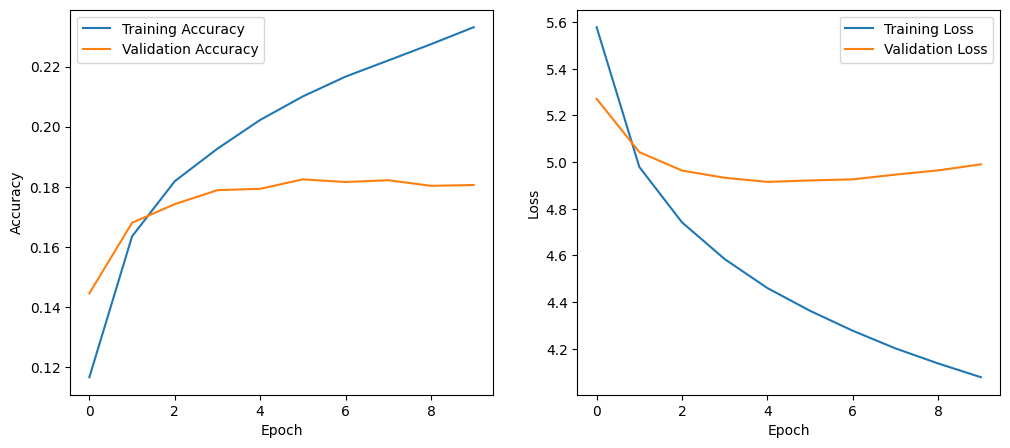

In [31]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()

plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

plt.show()

In [18]:

model.save("text_generation_lstm.keras")



In [32]:
print(generate_text("this food", 20))

print(generate_text("i love", 20))

print(generate_text("the taste", 20))

this food seasoning ups user york improve ganoderma introduced hunks common k realizing using guys parts shocked chooses which solution loves superb
i love dump chance mate pudding heb will discouraging salt reserve ranchero brm anonymous heavily stuffed normal there imperial damage if solution
the taste element fans below chewy healthy eith dollop interest disguise processor bliss chinese swiss defintely cramping ignore won suppressant terrific unopened
